# 🛒 Amazon Food Reviews Sentiment Analysis

## End-to-End Natural Language Processing & Machine Learning Project

### Project Overview

Customer reviews contain valuable information about customer satisfaction, product quality, and overall customer experience. However, manually analyzing thousands of reviews is time-consuming and difficult to scale.

This project builds an end-to-end Natural Language Processing (NLP) and Machine Learning pipeline to automatically classify Amazon food reviews as **Positive** or **Negative** based on the textual content of each review.

The project covers data exploration, text preprocessing, feature extraction using TF-IDF, machine learning model development, model evaluation, and sentiment prediction on new customer reviews.

### Business Objective

The objective is to develop a sentiment classification system that can help businesses:

- Automatically analyze large volumes of customer reviews
- Identify positive and negative customer sentiment
- Understand customer feedback at scale
- Detect potential customer dissatisfaction
- Support data-driven product and customer experience decisions

### Machine Learning Problem

This is a **supervised binary text classification problem**.

**Input:** Customer review text  
**Output:** Positive or Negative sentiment

## Import Required Libraries

The required Python libraries are imported for data manipulation, visualization, NLP preprocessing, feature extraction, machine learning, and model evaluation.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Text processing
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 200)

In [2]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jayes\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jayes\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Load the Dataset

The dataset contains Amazon food reviews along with ratings and other review-related information.

In [ ]:
DATA_PATH = r"...data\AmazonFoodReviews.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset Shape: 568,454 rows × 10 columns


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,"Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as ""Jumbo""."
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with ..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda. The fl...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,"Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taffy lover, this is a deal."


In [6]:
df.head(2)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,"Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as ""Jumbo""."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [5]:
print("Number of rows:", f"{df.shape[0]:,}")
print("Number of columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Number of rows: 568,454
Number of columns: 10

Columns:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


## Data Understanding & Quality Assessment

Before building the sentiment classification model, the dataset is examined for data quality issues such as missing values, duplicate records, unnecessary features, and the distribution of review ratings.

This step helps determine which variables are relevant for sentiment analysis and ensures that the data used for modeling is reliable.

In [7]:
# Missing values
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(df) * 100).round(2)
})

missing_df

,Missing Values,Percentage (%)
Id,0,0.0
ProductId,0,0.0
UserId,0,0.0
ProfileName,26,0.0
HelpfulnessNumerator,0,0.0
HelpfulnessDenominator,0,0.0
Score,0,0.0
Time,0,0.0
Summary,27,0.0
Text,0,0.0


### Duplicate Records

Duplicate reviews can introduce bias into the analysis and model evaluation. Therefore, duplicate records are identified before further processing.

In [8]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {(duplicate_count / len(df)) * 100:.2f}%")

Number of duplicate rows: 0
Duplicate percentage: 0.00%


### Review Rating Distribution

The `Score` column contains customer ratings ranging from 1 to 5. Examining its distribution helps us understand the overall customer sentiment and potential class imbalance.

In [11]:
score_counts = df["Score"].value_counts().sort_index()

score_counts

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

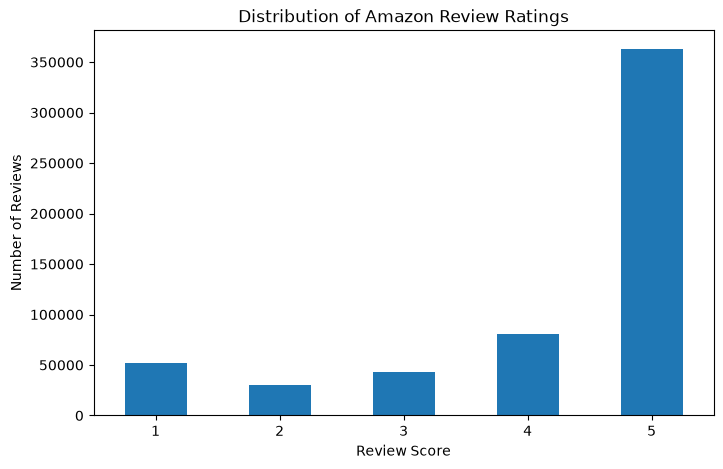

In [12]:
plt.figure(figsize=(8, 5))

score_counts.plot(kind="bar")

plt.title("Distribution of Amazon Review Ratings")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## Data Cleaning & Sentiment Label Creation

For sentiment classification, the review text and rating score are the most important features.

Customer ratings are converted into sentiment labels using the following rule:

- **1–2 stars → Negative**
- **3 stars → Neutral**
- **4–5 stars → Positive**

Since the objective of this project is binary sentiment classification, neutral (3-star) reviews are excluded from model training.

Duplicate review texts and records with missing review text are also handled to reduce redundancy and improve data quality.

In [13]:
# Select relevant columns for sentiment analysis
reviews_df = df[["Score", "Summary", "Text"]].copy()

print("Dataset shape:", reviews_df.shape)
reviews_df.head()

Dataset shape: (568454, 3)


,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labr...
1,1,Not as Advertised,"Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as ""Jumbo""."
2,4,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with ..."
3,2,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda. The fl...
4,5,Great taffy,"Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taffy lover, this is a deal."


In [14]:
print("Missing values:")
print(reviews_df.isnull().sum())

Missing values:
Score       0
Summary    27
Text        0
dtype: int64


In [15]:
# Remove records where review text is missing
reviews_df = reviews_df.dropna(subset=["Text"]).copy()

print(f"Records after removing missing review text: {len(reviews_df):,}")

Records after removing missing review text: 568,454


In [16]:
# Remove neutral reviews
reviews_df = reviews_df[reviews_df.Score != 3]

In [17]:
# Create new target columns
sentiment = []
for score in reviews_df['Score']:
    if score > 3:
        sentiment.append(1)
    else:
        sentiment.append(0)
reviews_df['Sentiment'] = sentiment

In [18]:
reviews_df["Sentiment"].value_counts()

Sentiment
1    443777
0     82037
Name: count, dtype: int64

In [19]:
sentiment_distribution = (
    reviews_df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_distribution

Sentiment
1    84.4
0    15.6
Name: proportion, dtype: float64

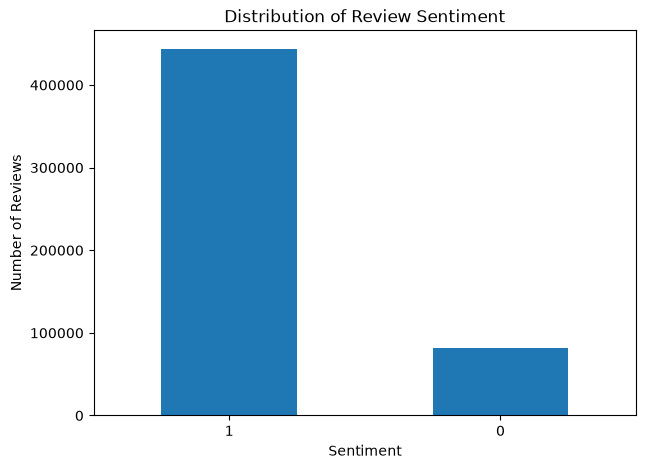

In [20]:
sentiment_counts = reviews_df["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))

sentiment_counts.plot(kind="bar")

plt.title("Distribution of Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [21]:
# handle duplicates
duplicate_text = reviews_df.duplicated(subset=["Text"]).sum()

print(f"Duplicate review texts: {duplicate_text:,}")
print(
    f"Percentage of duplicate review texts: "
    f"{duplicate_text / len(reviews_df) * 100:.2f}%"
)

Duplicate review texts: 161,978
Percentage of duplicate review texts: 30.81%


In [22]:
reviews_df = reviews_df.drop_duplicates(
    subset=["Text"],
    keep="first"
).copy()

reviews_df.reset_index(drop=True, inplace=True)

print(f"Final dataset size after cleaning: {reviews_df.shape}")

Final dataset size after cleaning: (363836, 4)


In [23]:
print("Missing Text:", reviews_df["Text"].isnull().sum())
print("Duplicate Text:", reviews_df.duplicated(subset=["Text"]).sum())

print("\nSentiment Distribution:")
print(reviews_df["Sentiment"].value_counts())

Missing Text: 0
Duplicate Text: 0

Sentiment Distribution:
Sentiment
1    306766
0     57070
Name: count, dtype: int64


## NLP Text Preprocessing

Customer reviews contain noise such as HTML tags, URLs, punctuation, numbers, special characters, and common words that may not contribute significantly to sentiment classification.

The review text is cleaned and normalized before converting it into numerical features.

The preprocessing pipeline includes:

1. Converting text to lowercase
2. Removing HTML tags
3. Removing URLs
4. Removing numbers and special characters
5. Removing selected stopwords
6. Lemmatizing words

Negation words such as **"not", "no", and "nor"** are preserved because they can significantly change the sentiment of a sentence.

In [24]:
#NLP resources

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import re

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))

# Preserve important negation words
negation_words = {"not", "no", "nor"}

stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

print("Number of stopwords used:", len(stop_words))

Number of stopwords used: 195


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jayes\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jayes\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jayes\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [27]:
# Build one reusable preprocessing function

def preprocess_text(text):
    """
    Clean and preprocess review text for sentiment analysis.
    """

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Keep alphabetic characters and apostrophes
    text = re.sub(r"[^a-z']", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize using whitespace
    words = text.split()

    # Remove stopwords and very short tokens
    words = [
        word for word in words
        if word not in stop_words and len(word) > 1
    ]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [26]:
sample_review = """
I did not like this product at all! The quality was terrible,
but the delivery was very fast. <br /> Visit www.example.com
"""

print("Original:")
print(sample_review)

print("\nCleaned:")
print(preprocess_text(sample_review))

Original:

I did not like this product at all! The quality was terrible,
but the delivery was very fast. <br /> Visit www.example.com


Cleaned:
not like product quality terrible delivery fast visit


In [28]:
# Compare actual Amazon reviews
for i in range(3):
    print(f"\nREVIEW {i + 1}")
    print("-" * 80)

    print("Original:")
    print(reviews_df["Text"].iloc[i][:500])

    print("\nCleaned:")
    print(preprocess_text(reviews_df["Text"].iloc[i])[:500])


REVIEW 1
--------------------------------------------------------------------------------
Original:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

Cleaned:
bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better

REVIEW 2
--------------------------------------------------------------------------------
Original:
Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

Cleaned:
product arrived labeled jumbo salted peanut peanut actually small sized unsalted not sure error vendor intended represent product jumbo

REVIEW 3
---------------

In [30]:
#Apply preprocessing
reviews_df["Cleaned_Text"] = reviews_df["Text"].apply(preprocess_text)

In [31]:
reviews_df[["Text", "Cleaned_Text", "Sentiment"]].head()

,Text,Cleaned_Text,Sentiment
0,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labr...,bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better,1
1,"Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as ""Jumbo"".",product arrived labeled jumbo salted peanut peanut actually small sized unsalted not sure error vendor intended represent product jumbo,0
2,"This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with ...",confection around century light pillowy citrus gelatin nut case filbert cut tiny square liberally coated powdered sugar tiny mouthful heaven not chewy flavorful highly recommend yummy treat famili...,1
3,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda. The fl...,looking secret ingredient robitussin believe found got addition root beer extract ordered good made cherry soda flavor medicinal,0
4,"Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taffy lover, this is a deal.",great taffy great price wide assortment yummy taffy delivery quick taffy lover deal,1


In [32]:
# Check for empty reviews after preprocessing
empty_reviews = (reviews_df["Cleaned_Text"].str.strip() == "").sum()

print(f"Empty reviews after preprocessing: {empty_reviews:,}")

Empty reviews after preprocessing: 2


In [33]:
reviews_df = reviews_df[
    reviews_df["Cleaned_Text"].str.strip() != ""
].copy()

reviews_df.reset_index(drop=True, inplace=True)

print(f"Dataset after text preprocessing: {reviews_df.shape}")

Dataset after text preprocessing: (363834, 5)


In [34]:
# Review-Length Feature for EDA

reviews_df["Review_Length"] = reviews_df["Text"].str.split().str.len()

reviews_df["Review_Length"].describe()

count    363834.000000
mean         78.411383
std          75.979922
min           3.000000
25%          33.000000
50%          56.000000
75%          96.000000
max        2520.000000
Name: Review_Length, dtype: float64

In [35]:
reviews_df.groupby("Sentiment")["Review_Length"].agg(
    ["mean", "median", "min", "max"]
).round(2)

,mean,median,min,max
Sentiment,,,,
0,85.25,63.0,3,2149
1,77.14,54.0,3,2520


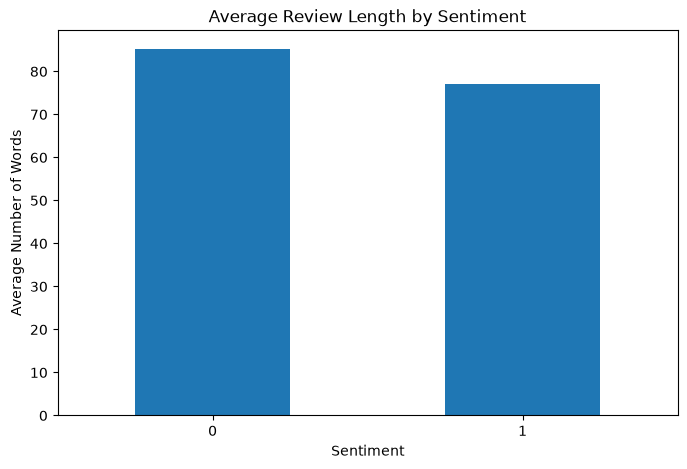

In [36]:
plt.figure(figsize=(8, 5))

reviews_df.groupby("Sentiment")["Review_Length"].mean().plot(
    kind="bar"
)

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)
plt.show()

## Exploratory Analysis of Review Text

After preprocessing, the review text is explored to understand which words occur most frequently in positive and negative customer feedback.

Comparing word patterns across sentiment classes can reveal common themes in customer satisfaction and dissatisfaction.

In [37]:
# Most frequent words

from collections import Counter

def get_top_words(text_series, n=15):
    all_words = " ".join(text_series).split()
    return Counter(all_words).most_common(n)

In [38]:
positive_reviews = reviews_df.loc[
    reviews_df["Sentiment"] == "Positive", "Cleaned_Text"
]

negative_reviews = reviews_df.loc[
    reviews_df["Sentiment"] == "Negative", "Cleaned_Text"
]

top_positive_words = get_top_words(positive_reviews)
top_negative_words = get_top_words(negative_reviews)

print("Top Positive Review Words:")
print(top_positive_words)

print("\nTop Negative Review Words:")
print(top_negative_words)

Top Positive Review Words:
[]

Top Negative Review Words:
[]


## Preparing Data for Machine Learning

The cleaned review text is used as the input feature and the sentiment label as the target variable.

The dataset is divided into training and testing sets before TF-IDF vectorization. This ensures that the model is evaluated using reviews it did not see during training.

A stratified split is used to preserve the original positive and negative class distribution in both datasets.

In [41]:
X = reviews_df["Cleaned_Text"]
y = reviews_df["Sentiment"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (363834,)
Target shape: (363834,)


In [42]:
# train test split 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training reviews: {len(X_train):,}")
print(f"Testing reviews:  {len(X_test):,}")

Training reviews: 291,067
Testing reviews:  72,767


In [43]:
print("Training distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training distribution:
Sentiment
1    0.843
0    0.157
Name: proportion, dtype: float64

Testing distribution:
Sentiment
1    0.843
0    0.157
Name: proportion, dtype: float64


## TF-IDF Feature Extraction

Machine learning algorithms cannot directly process raw text. Therefore, the cleaned reviews are converted into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency)**.

TF-IDF gives higher importance to words that are informative within a review while reducing the influence of words that occur very frequently across the entire dataset.

Both individual words and two-word combinations (bigrams) are considered to capture additional context such as **"not good"** or **"highly recommend"**.

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (291067, 50000)
Testing TF-IDF shape: (72767, 50000)


In [45]:
tfidf.fit_transform(X_train)
tfidf.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3377117 stored elements and shape (72767, 50000)>

## Machine Learning Model Development

To identify an effective classifier for sentiment prediction, multiple machine learning algorithms are trained and evaluated using the same TF-IDF features.

The following models are compared:

1. **Logistic Regression** – A strong and interpretable baseline for text classification.
2. **Multinomial Naive Bayes** – A probabilistic algorithm commonly used for NLP and text classification.
3. **Linear Support Vector Machine (LinearSVC)** – A linear classifier that performs well with high-dimensional sparse text features.

Model performance is compared using Accuracy, Precision, Recall, and F1-score.

**1. Logistic Regression Model**

In [46]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

lr_predictions = logistic_model.predict(X_test_tfidf)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, lr_predictions):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, lr_predictions))

LOGISTIC REGRESSION RESULTS
Accuracy : 0.9159

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.91      0.77     11414
           1       0.98      0.92      0.95     61353

    accuracy                           0.92     72767
   macro avg       0.83      0.91      0.86     72767
weighted avg       0.93      0.92      0.92     72767



**Logistic Regression Confusion Matrix**

The confusion matrix shows how many positive and negative reviews were correctly and incorrectly classified by the model.

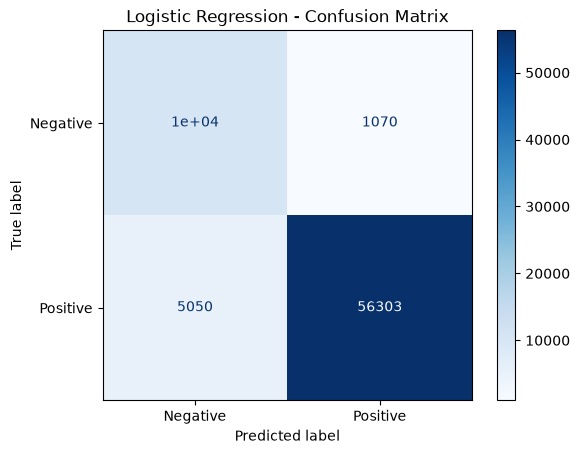

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions,
    labels=[0, 1],
    display_labels=["Negative", "Positive"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

**Multinomial Naive Bayes Model**

Multinomial Naive Bayes is commonly used for text classification because it works efficiently with word-frequency and TF-IDF representations.

It provides a useful benchmark against Logistic Regression.

In [62]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes training completed.")

Multinomial Naive Bayes training completed.


In [63]:
print("MULTINOMIAL NAIVE BAYES RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, nb_predictions):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, nb_predictions))

MULTINOMIAL NAIVE BAYES RESULTS
Accuracy : 0.9137

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.51      0.65     11414
           1       0.92      0.99      0.95     61353

    accuracy                           0.91     72767
   macro avg       0.91      0.75      0.80     72767
weighted avg       0.91      0.91      0.90     72767



**Linear Support Vector Machine**

Linear Support Vector Machine is well suited for high-dimensional sparse datasets such as TF-IDF text representations.

The model attempts to find a decision boundary that best separates positive and negative customer reviews.

In [64]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_predictions = svm_model.predict(X_test_tfidf)

print("Linear SVM training completed.")

Linear SVM training completed.


In [65]:
print("LINEAR SVM RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, svm_predictions):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, svm_predictions))

LINEAR SVM RESULTS
Accuracy : 0.9247

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.86      0.78     11414
           1       0.97      0.94      0.95     61353

    accuracy                           0.92     72767
   macro avg       0.84      0.90      0.87     72767
weighted avg       0.93      0.92      0.93     72767



## All Model Comparison 

All three models are evaluated on the same unseen test dataset. Their performance is compared using Accuracy, Precision, Recall, and F1-score.

In [69]:
def evaluate_model(y_true, predictions):
    return {
        "Accuracy": accuracy_score(y_true, predictions),

        "Precision": precision_score(
            y_true, predictions, pos_label=1
        ),

        "Recall": recall_score(
            y_true, predictions, pos_label=1
        ),

        "F1 Score": f1_score(
            y_true, predictions, pos_label=1
        ),

        "Macro F1": f1_score(
            y_true, predictions, average="macro"
        )
    }


results = pd.DataFrame({
    "Logistic Regression": evaluate_model(y_test, lr_predictions),
    "Naive Bayes": evaluate_model(y_test, nb_predictions),
    "Linear SVM": evaluate_model(y_test, svm_predictions)
}).T

results.round(4)

,Accuracy,Precision,Recall,F1 Score,Macro F1
Logistic Regression,0.9159,0.9814,0.9177,0.9485,0.8601
Naive Bayes,0.9137,0.9151,0.9894,0.9508,0.7994
Linear SVM,0.9247,0.9737,0.9361,0.9545,0.8686


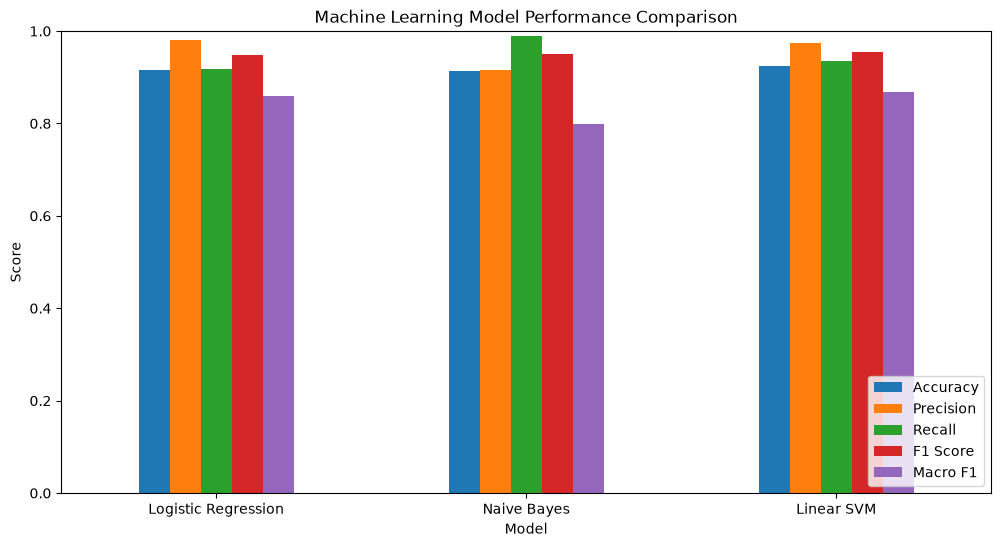

In [70]:
results.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## Final Model Selection

The models are compared using multiple evaluation metrics rather than accuracy alone.

Since the dataset contains an unequal distribution of positive and negative reviews, **Macro F1-score** is considered an important metric because it gives equal importance to both sentiment classes.

The model with the highest Macro F1-score is selected as the final sentiment classifier.

In [71]:
best_model_name = results["Macro F1"].idxmax()
best_macro_f1 = results.loc[best_model_name, "Macro F1"]

print("Selected Model:", best_model_name)
print(f"Macro F1 Score: {best_macro_f1:.4f}")

Selected Model: Linear SVM
Macro F1 Score: 0.8686


In [72]:
model_map = {
    "Logistic Regression": logistic_model,
    "Naive Bayes": nb_model,
    "Linear SVM": svm_model
}

prediction_map = {
    "Logistic Regression": lr_predictions,
    "Naive Bayes": nb_predictions,
    "Linear SVM": svm_predictions
}

final_model = model_map[best_model_name]
final_predictions = prediction_map[best_model_name]

print(f"Final model selected: {best_model_name}")

Final model selected: Linear SVM


## Final Model Evaluation

The selected model is evaluated in greater detail to understand its performance across both positive and negative customer reviews.

In [73]:
print(f"Classification Report - {best_model_name}")
print("=" * 60)

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["Negative", "Positive"]
    )
)

Classification Report - Linear SVM
              precision    recall  f1-score   support

    Negative       0.72      0.86      0.78     11414
    Positive       0.97      0.94      0.95     61353

    accuracy                           0.92     72767
   macro avg       0.84      0.90      0.87     72767
weighted avg       0.93      0.92      0.93     72767



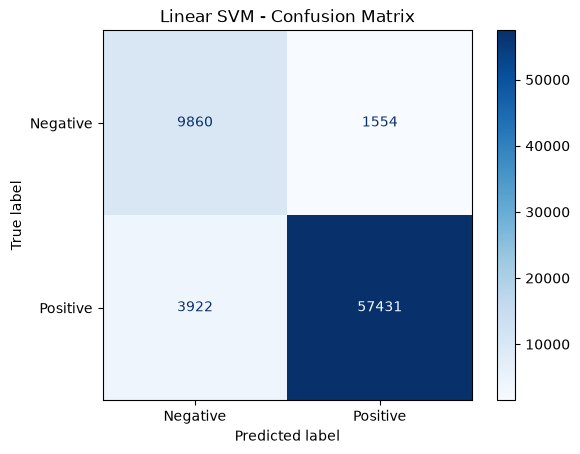

In [74]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    labels=[0, 1],
    display_labels=["Negative", "Positive"],
    cmap="Blues"
)

plt.title(f"{best_model_name} - Confusion Matrix")
plt.show()

## 15. Error Analysis

Model evaluation metrics provide an overall measure of performance, but examining incorrectly classified reviews helps identify situations where the sentiment classifier struggles.

False positives and false negatives are analyzed to better understand the model's limitations.

In [75]:
error_analysis = pd.DataFrame({
    "Review": X_test,
    "Actual": y_test,
    "Predicted": final_predictions
})

error_analysis["Actual"] = error_analysis["Actual"].map({
    0: "Negative",
    1: "Positive"
})

error_analysis["Predicted"] = error_analysis["Predicted"].map({
    0: "Negative",
    1: "Positive"
})

errors = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
]

print(f"Total test reviews: {len(error_analysis):,}")
print(f"Misclassified reviews: {len(errors):,}")

errors.head(10)

Total test reviews: 72,767
Misclassified reviews: 5,476


,Review,Actual,Predicted
101913,first admit offered coffee review saw single serve pod assumed meant keurig not apparently actual coffeemakers take pod duh received bit maneuvering actually use worked fine cut open pod put coffe...,Positive,Negative
39759,great deal coffee that's partially least rain forest certified two can got date bottom making think maybe not freshest can around bought month ago that's lot coffee use december far coffee's ok no...,Positive,Negative
61621,taste decent fat chemical tried taco fajitas grilled poultry true sauce bring something meal cost flavor fat chemical,Positive,Negative
89150,remember eating product many year ago kid sometimes can't go home no flavor even dog eat gave neighbor kid eat anything,Negative,Positive
244863,really buy product know desire feed one's cat cat food cost per oz symptom something cat would rather eat live roach fly turd packaged fish based product already know bargain take,Positive,Negative
52344,like bean pea antioxidant rich starch corn somewhat high calorie however eating corn without salt help u live longer also yellow corn not white corn contains generous amount carotenoid lutein zeax...,Positive,Negative
334278,thoroughly loved london ordered last winter yay no problem ordered end july aaaahhhhhhhhhhh squishy stuck freezer hope save skeptical survive seriously suggest not buy summer thinking,Positive,Negative
15443,standard good cup would green mountain extra bold expresso hard find around sixty cent less serving tried brand friend gave cup office batch lot weaker not sure coffee content less friend batch en...,Negative,Positive
236664,taste better eat dark look like something would clean drain said taste okay distinct 'powdery' spice taste course dealing bagged snack guess expected find surprisingly filling come price high calo...,Negative,Positive
19402,live dog lb shepherd collie mix lb spaniel mix lb chihuahua dachshund mix chiweenie get food toy good thing really one weight problem also youngest one likely get trouble left home alone drag toy ...,Positive,Negative


In [76]:
false_positives = errors[
    (errors["Actual"] == "Negative") &
    (errors["Predicted"] == "Positive")
]

false_positives.head(5)

,Review,Actual,Predicted
89150,remember eating product many year ago kid sometimes can't go home no flavor even dog eat gave neighbor kid eat anything,Negative,Positive
15443,standard good cup would green mountain extra bold expresso hard find around sixty cent less serving tried brand friend gave cup office batch lot weaker not sure coffee content less friend batch en...,Negative,Positive
236664,taste better eat dark look like something would clean drain said taste okay distinct 'powdery' spice taste course dealing bagged snack guess expected find surprisingly filling come price high calo...,Negative,Positive
303422,serve blk water brita filter would cause nuclear reaction mmmm breakfast green egg ham blk water,Negative,Positive
187880,buy many many thing amazon certainly not allegro marinade get wrong allegro one best marinade's ever used make sell beef jerky small scale year many people many recipe jerky trial error chosen all...,Negative,Positive


In [77]:
false_negatives = errors[
    (errors["Actual"] == "Positive") &
    (errors["Predicted"] == "Negative")
]

false_negatives.head(5)

,Review,Actual,Predicted
101913,first admit offered coffee review saw single serve pod assumed meant keurig not apparently actual coffeemakers take pod duh received bit maneuvering actually use worked fine cut open pod put coffe...,Positive,Negative
39759,great deal coffee that's partially least rain forest certified two can got date bottom making think maybe not freshest can around bought month ago that's lot coffee use december far coffee's ok no...,Positive,Negative
61621,taste decent fat chemical tried taco fajitas grilled poultry true sauce bring something meal cost flavor fat chemical,Positive,Negative
244863,really buy product know desire feed one's cat cat food cost per oz symptom something cat would rather eat live roach fly turd packaged fish based product already know bargain take,Positive,Negative
52344,like bean pea antioxidant rich starch corn somewhat high calorie however eating corn without salt help u live longer also yellow corn not white corn contains generous amount carotenoid lutein zeax...,Positive,Negative


## Predicting Sentiment of New Reviews

A reusable prediction function is created to classify previously unseen customer reviews.

The function applies the same preprocessing and TF-IDF transformation used during model training before generating the sentiment prediction.

In [78]:
def predict_sentiment(review):
    
    # Preprocess review
    cleaned_review = preprocess_text(review)

    # Convert text into TF-IDF features
    review_tfidf = tfidf.transform([cleaned_review])

    # Generate prediction
    prediction = final_model.predict(review_tfidf)[0]

    sentiment = "Positive" if prediction == 1 else "Negative"

    return sentiment

In [79]:
review_1 = "This product tastes amazing and I would definitely buy it again."

review_2 = "Very disappointed with the quality. It tasted terrible."

review_3 = "The delivery was quick but I did not like the taste at all."

print("Review 1:", predict_sentiment(review_1))
print("Review 2:", predict_sentiment(review_2))
print("Review 3:", predict_sentiment(review_3))

Review 1: Positive
Review 2: Negative
Review 3: Negative


In [80]:
# Cleaner Demo
def analyze_review(review):

    cleaned_review = preprocess_text(review)
    review_tfidf = tfidf.transform([cleaned_review])
    prediction = final_model.predict(review_tfidf)[0]

    sentiment = "Positive" if prediction == 1 else "Negative"

    print("CUSTOMER REVIEW")
    print("-" * 70)
    print(review)

    print("\nPREDICTED SENTIMENT")
    print("-" * 70)
    print(sentiment)

In [81]:
analyze_review(
    "The product was fresh, delicious and arrived on time. Highly recommended!"
)

CUSTOMER REVIEW
----------------------------------------------------------------------
The product was fresh, delicious and arrived on time. Highly recommended!

PREDICTED SENTIMENT
----------------------------------------------------------------------
Positive


## Business Applications

An automated sentiment analysis system can help businesses transform large volumes of customer feedback into useful information.

Potential applications include:

- **Customer Feedback Monitoring:** Automatically categorize large volumes of reviews as positive or negative.
- **Early Issue Detection:** Identify negative feedback that may require further investigation.
- **Product Experience Analysis:** Analyze sentiment patterns across products or product categories when corresponding metadata is available.
- **Customer Experience Support:** Help teams prioritize dissatisfied customer feedback for further review.
- **Large-Scale Review Analysis:** Reduce the manual effort required to examine thousands of customer reviews.

##  Project Limitations

Although the sentiment classification pipeline provides a useful approach for analyzing customer reviews, several limitations should be considered:

- Sentiment labels are derived from star ratings rather than manually annotated sentiment.
- Three-star reviews are excluded to create a binary classification problem.
- Traditional TF-IDF features have limited ability to understand deeper semantic context.
- Complex language such as sarcasm, mixed sentiment, and context-dependent expressions may be difficult to classify.
- The model predicts overall review sentiment and does not identify sentiment toward individual product attributes.
- Model performance may change when applied to reviews from different domains or time periods.

## Future Improvements

Possible extensions of this project include:

- Hyperparameter tuning using cross-validation
- Experimenting with additional n-gram configurations
- Comparing traditional ML models with deep learning approaches
- Using pretrained transformer models such as BERT for contextual text understanding
- Performing aspect-based sentiment analysis
- Building an interactive application using Streamlit
- Deploying the sentiment classifier as an API or web application

In [82]:
# Final Conclusion

print("FINAL PROJECT SUMMARY")
print("=" * 60)

print(f"Dataset used after cleaning : {len(reviews_df):,} reviews")
print(f"Training samples            : {len(X_train):,}")
print(f"Testing samples             : {len(X_test):,}")
print(f"TF-IDF features             : {X_train_tfidf.shape[1]:,}")
print(f"Selected model              : {best_model_name}")
print(f"Accuracy                    : {results.loc[best_model_name, 'Accuracy']:.4f}")
print(f"Macro F1                    : {results.loc[best_model_name, 'Macro F1']:.4f}")

FINAL PROJECT SUMMARY
Dataset used after cleaning : 363,834 reviews
Training samples            : 291,067
Testing samples             : 72,767
TF-IDF features             : 50,000
Selected model              : Linear SVM
Accuracy                    : 0.9247
Macro F1                    : 0.8686


## Conclusion

This project developed an end-to-end Natural Language Processing and Machine Learning pipeline for classifying Amazon food reviews into positive and negative sentiment.

The workflow covered data quality assessment, sentiment label creation, text preprocessing, exploratory text analysis, TF-IDF feature extraction, machine learning model development, comparative evaluation, error analysis, and prediction on unseen customer reviews.

Multiple classification algorithms were evaluated using several performance metrics. Particular attention was given to class-level performance and Macro F1-score because of the imbalance between positive and negative reviews.

The project demonstrates how unstructured customer feedback can be transformed into structured sentiment information using traditional NLP and machine learning techniques.